## Prepare imports

In [88]:
from datasets import get_datasets, synsetid_to_cate
from args import get_parser
import torch
import numpy as np
import pyvista as pv
import seaborn as sns 
import pandas as pd


def plot_pcs_single(pcs, offset=0):
    
    max_cols = min(len(pcs), 10)
    print(len(pcs))
    pl = pv.Plotter(
        shape=(1, max_cols),
        window_size=[max_cols * 200, 200],
        border=False,
        polygon_smoothing=True,
    )

    for col in range(max_cols):
        points = pcs[col + offset].reshape(-1, 3).detach().cpu().numpy()
        pl.subplot(0, col)
        actor = pl.add_points(
            points,
            style="points",
            emissive=False,
            show_scalar_bar=False,
            render_points_as_spheres=True,
            scalars=points[:, 2],
            point_size=2,
            ambient=0.2,
            diffuse=0.8,
            specular=0.8,
            specular_power=40,
            smooth_shading=True,
        )

    pl.background_color = "w"
    pl.link_views()
    pl.camera_position = "xy"
    pos = pl.camera.position
    pl.camera.position = (pos[0], pos[1] + 3, pos[2])
    pl.camera.position = (6, 0, 0)
    pl.camera.azimuth = 45
    pl.camera.elevation = 30
    # create a top down light
    light = pv.Light(
        position=(0, 0, 0), positional=True, cone_angle=50, exponent=20, intensity=0.2
    )
    pl.add_light(light)
    pl.camera.zoom(1.3)
    pl.show()


In [89]:
p = get_parser()
args, unknown = p.parse_known_args({"fast_run":False})


In [90]:
data_records = []
for cate in ["airplane", "car","chair"]: 

    args.cates = [cate]
    tr_dataset, te_dataset = get_datasets(args)
    
    #  Bounding norms
    tr_bounding_norms = torch.tensor(tr_dataset.test_points).norm(dim=-1).max(dim=-1)[0]
    tr_object_norms = (torch.tensor(tr_dataset.test_points) - torch.tensor(tr_dataset.test_points).mean(dim=-2,keepdim=True)).norm(dim=-1).max(dim=-1)[0]

    data_records.extend([
        {"bounding_norm":bn.item(),
        "object_norm":objn.item(), 
        "cate":cate, 
        "split":"train"} for bn,objn in zip(tr_bounding_norms,tr_object_norms)
    ])


    te_bounding_norms = torch.tensor(te_dataset.test_points).norm(dim=-1).max(dim=-1)[0]
    te_object_norms = (torch.tensor(te_dataset.test_points) - torch.tensor(te_dataset.test_points).mean(dim=-2,keepdim=True)).norm(dim=-1).max(dim=-1)[0]

    data_records.extend([
        {"bounding_norm":bn.item(),
         "cate":cate, 
        "object_norm":objn.item(), 
        "split":"test"} for bn,objn in zip(te_bounding_norms,tr_object_norms)
    ])

Total number of data:2831
Min number of points: (train)2048 (test)2048
Total number of data:405
Min number of points: (train)2048 (test)2048
Total number of data:2458
Min number of points: (train)2048 (test)2048
Total number of data:352
Min number of points: (train)2048 (test)2048
Total number of data:4612
Min number of points: (train)2048 (test)2048
Total number of data:662
Min number of points: (train)2048 (test)2048


In [80]:
df = pd.DataFrame(data_records)

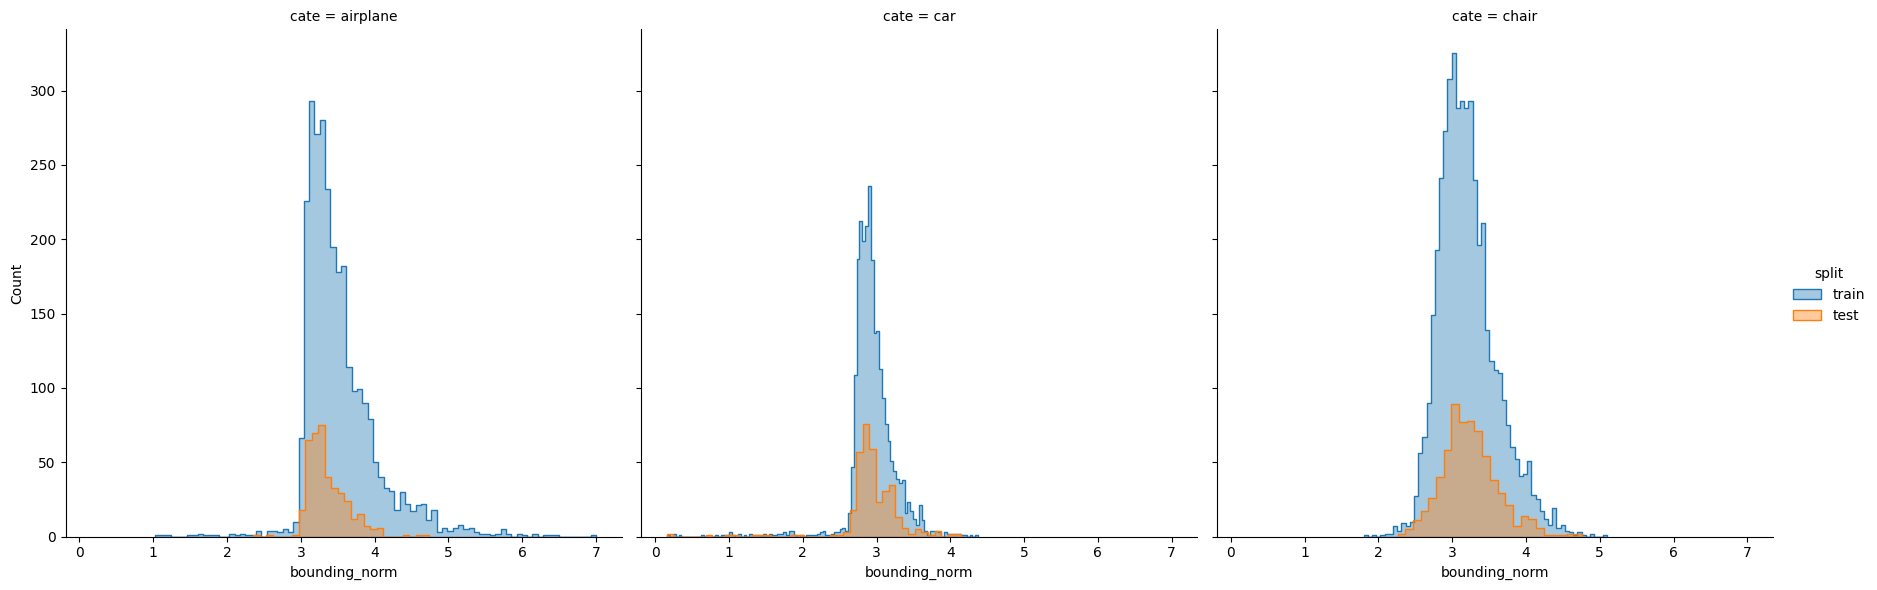

In [76]:
g = sns.FacetGrid(df,col="cate",hue="split", sharex=True, sharey=True,height=6)
g.map(sns.histplot,"bounding_norm",element="step",alpha=.4);
g.add_legend()

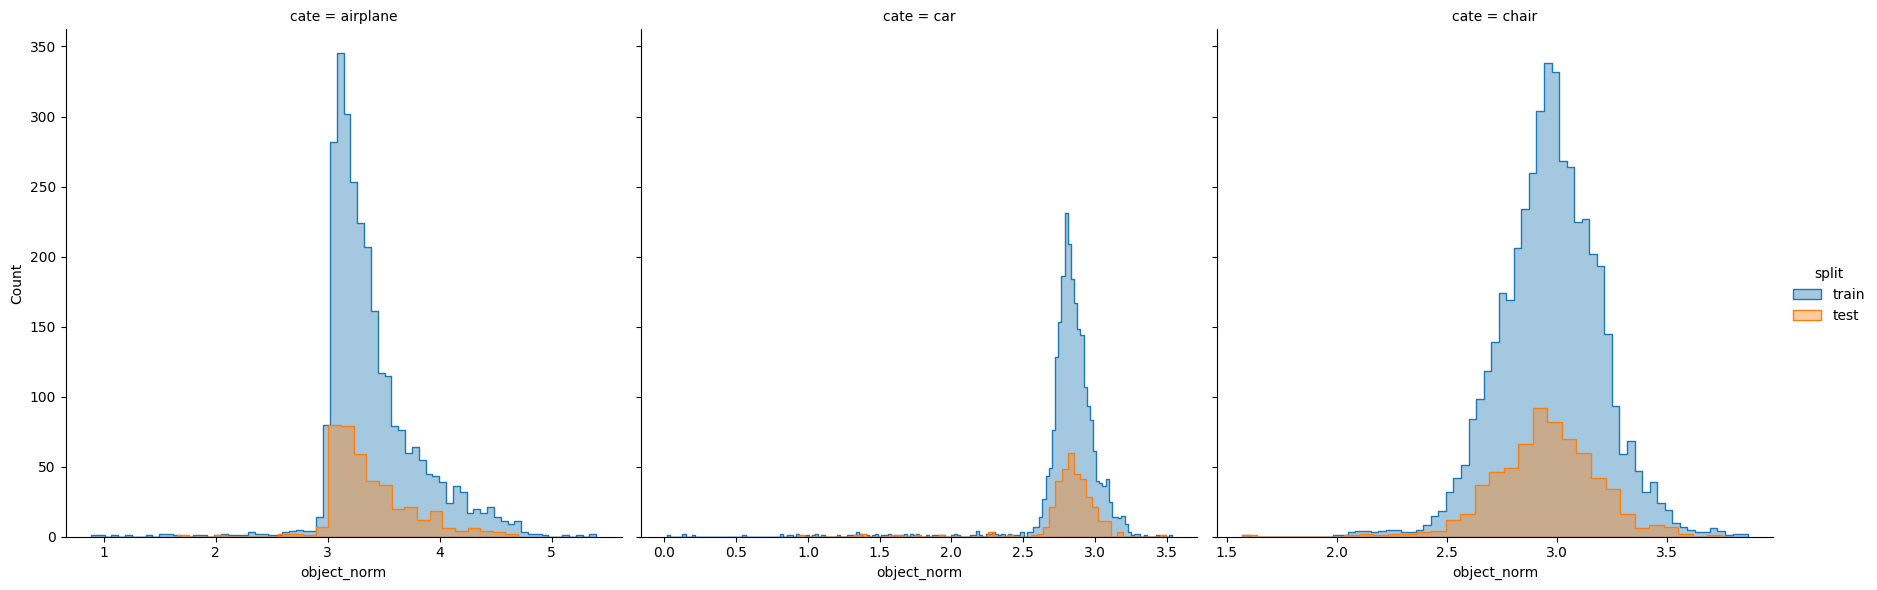

In [79]:
g = sns.FacetGrid(df,col="cate",hue="split", sharex=False, sharey=True,height=6);
g.map(sns.histplot,"object_norm",element="step",alpha=.4);
g.add_legend();

In [87]:
df.groupby(["cate","split"]).agg(["max","min","mean","std"])

bounding_norm                               object_norm  \
                         max       min      mean       std         max   
cate     split                                                           
airplane test       4.737068  2.351758  3.356571  0.271843    4.701441   
         train      7.004415  1.023460  3.525220  0.506062    5.399612   
car      test       4.140443  0.155252  2.938037  0.411427    3.493170   
         train      4.376009  0.164546  2.935811  0.329161    3.537390   
chair    test       4.761164  2.259321  3.240014  0.379790    3.749991   
         train      5.095252  1.799989  3.206122  0.388422    3.867768   

                                              
                     min      mean       std  
cate     split                                
airplane test   1.650646  3.387165  0.371939  
         train  0.884725  3.393570  0.410039  
car      test   0.934191  2.823713  0.241697  
         train  0.014833  2.819778  0.263283  
chair    test   1.570907  2.952361  0.235538  
         train  1.570907  2.972191  0.227818

In [91]:
2048*3

6144